In [1]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

In [2]:
import cvxpy as cp
import pdb
import pandas as pd

ModuleNotFoundError: No module named 'cvxpy'

In [293]:
# Lineinf_numbered.txt -> 2D object array (keeps strings + numbers)
df_line_num = pd.read_csv("/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Lineinf_numbered_bfs.txt", sep=r"\s+", engine="python")
Lineinf_numbered = df_line_num.to_numpy(object)
print(Lineinf_numbered.shape, Lineinf_numbered.dtype)
print(Lineinf_numbered)

# Loadinf_numbered.txt -> 2D object array
df_load_num = pd.read_csv("/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Loadinf_numbered_bfs.txt", sep=r"\s+", engine="python")
Loadinf_numbered = df_load_num.to_numpy(object)
print(Loadinf_numbered.shape, Loadinf_numbered.dtype)

(1039, 19) object
[[1 2 '_mdv_sub_1_lsb' ... 400.0 600.0 'mdv201_connector']
 [804 817 '94743' ... 163.0 196.0 'mdv201_hn_1_275_a94744']
 [365 389 '62244' ... 218.0 262.0 'mdv201_hn_2_466_c62235']
 ...
 [606 625 '39597' ... 125.0 150.0 'mdv201_hn_2_097_a39598']
 [662 677 '1160456' ... 400.0 600.0 'c_1p029_sw']
 [677 691 'mdv201_8107elb_int' ... 2000.0 2000.0 'mdv201_8107elb']]
(591, 11) object


In [294]:
Lineinf = Lineinf_numbered[:, :][:, np.r_[0,1,4:16]]
#print(Lineinf)

Lineinf = np.vectorize(lambda z: float(str(z).strip().strip('[]')))(Lineinf)

Loadinf = Loadinf_numbered[:, :][:, np.r_[0,2:11]]
Loadinf = np.vectorize(lambda z: float(str(z).strip().strip('[]')))(Loadinf)

#print(Loadinf)

In [295]:
# Base values
brs = Lineinf.shape[0]+1
baseMVA = 1e6
baseV = 12.47e3 / np.sqrt(3)
baseZ = baseV**2 / baseMVA

In [296]:
node1 = Lineinf[:,0].astype(int)
node2 = Lineinf[:,1].astype(int)
node = np.unique(np.concatenate([node1, node2]))
tnode = int(node.max())

#print(node1, node2)

In [297]:
# from and to bus columns
fb = Lineinf[:, 0].astype(int)
tb = Lineinf[:, 1].astype(int)

node1 = Lineinf[:,0].astype(int)
node2 = Lineinf[:,1].astype(int)
node = np.unique(np.concatenate([node1, node2]))
tnode = int(node.max())

# create the network graph
G = nx.Graph()
edges = list(zip(fb, tb))
G.add_edges_from(edges)

In [298]:
import plotly.graph_objects as go

# Get positions
pos = nx.kamada_kawai_layout(G)

# Create edge traces
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(x=edge_x, y=edge_y, mode='lines',
                        line=dict(width=1, color='gray'), hoverinfo='none')

# Create node traces
node_x = [pos[node][0] for node in G.nodes()]
node_y = [pos[node][1] for node in G.nodes()]
node_text = [str(node) for node in G.nodes()]

node_trace = go.Scatter(x=node_x, y=node_y, mode='markers+text',
                        text=node_text, textposition='top center',
                        marker=dict(size=15, color='lightblue', line_width=2),
                        hoverinfo='text')

fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(title='Network Topology (Interactive)',
                                showlegend=False, hovermode='closest',
                                margin=dict(b=0,l=0,r=0,t=40),
                                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)))
fig.show()


In [299]:
# ---------------------------------------------------------------------------------
# AUTOMATIC INCIDENCE MATRIX GENERATION (CORRECTED FOR 1-INDEXED BRANCHES)
# ---------------------------------------------------------------------------------
def generate_incidence_matrices(Lineinf, tnode, root_node=1):
    """
    Automatically generate incidence and outgoing branch matrices for a radial network.
    Branch indices are 1-indexed to match the original convention.

    Parameters:
    -----------
    Lineinf : numpy array
        Line information matrix where first two columns are from_node and to_node
    tnode : int
        Total number of nodes
    root_node : int
        Root node (slack bus) number (default=1)

    Returns:
    --------
    incbr : numpy array
        Incoming branch index for each node (1-indexed branches, except root which is 0)
    outbr : numpy array
        Outgoing branch indices for each node (1-indexed branches)
    branch_dict : dict
        Dictionary mapping (from_node, to_node) -> branch_index
    """

    print("\n" + "="*60)
    print("GENERATING INCIDENCE MATRICES AUTOMATICALLY")
    print("="*60)

    # Create undirected graph
    G = nx.Graph()

    # Add edges with branch indices (1-INDEXED for branches)
    branch_dict = {}
    for idx, line in enumerate(Lineinf):
        from_node = int(line[0])
        to_node = int(line[1])

        # Store branch index as 1-indexed (idx + 1)
        branch_idx_1based = idx + 1
        branch_dict[(from_node, to_node)] = branch_idx_1based
        branch_dict[(to_node, from_node)] = branch_idx_1based

        # Add edge to graph
        G.add_edge(from_node, to_node, branch=branch_idx_1based)

    # Build tree structure using BFS from root
    print(f"\nBuilding tree structure from root node {root_node}...")

    # Find parent-child relationships
    parent = {}
    children = {i: [] for i in range(1, tnode + 1)}
    incoming_branch = {}

    # BFS to establish tree structure
    visited = set([root_node])
    queue = [root_node]
    parent[root_node] = None
    incoming_branch[root_node] = 0  # Root has incoming branch 0

    while queue:
        current = queue.pop(0)

        # Find all neighbors (sorted for consistency)
        neighbors = sorted(G.neighbors(current))

        for neighbor in neighbors:
            if neighbor not in visited:
                visited.add(neighbor)
                parent[neighbor] = current
                children[current].append(neighbor)

                # Get branch index (already 1-indexed)
                branch_idx = G[current][neighbor]['branch']
                incoming_branch[neighbor] = branch_idx

                queue.append(neighbor)

    # Verify all nodes are visited
    if len(visited) != tnode:
        unvisited = set(range(1, tnode + 1)) - visited
        print(f"⚠️  Warning: Not all nodes visited. Unvisited nodes: {unvisited}")

    # Create incbr array
    incbr = np.zeros(tnode, dtype=int)
    for node_id in range(1, tnode + 1):
        if node_id in incoming_branch:
            incbr[node_id - 1] = incoming_branch[node_id]

    # Create outbr array
    max_children = max(len(children[i]) for i in range(1, tnode + 1))
    if max_children == 0:
        max_children = 1

    outbr = np.zeros((tnode, max_children), dtype=int)

    for node_id in range(1, tnode + 1):
        # Get children branches (sorted by branch index)
        child_branches = []
        for child in children[node_id]:
            if child in incoming_branch:
                child_branches.append(incoming_branch[child])

        # Sort branches
        child_branches.sort()

        # Fill outgoing branches
        for idx, branch in enumerate(child_branches[:max_children]):
            outbr[node_id - 1, idx] = branch

    # Print network structure
    print("\nNetwork Tree Structure:")
    print("-" * 60)

    def print_tree(node, level=0):
        indent = "  " * level
        inc_br = incoming_branch.get(node, 0)
        out_brs = sorted([incoming_branch[c] for c in children[node] if c in incoming_branch])
        print(f"{indent}Node {node:2d}: inc_br={inc_br:2d}, out_brs={out_brs}, children={sorted(children[node])}")
        for child in sorted(children[node]):
            print_tree(child, level + 1)

    print_tree(root_node)

    # Print summary
    print("\n" + "-" * 60)
    print("Incidence Matrix Summary:")
    print(f"  Shape: incbr={incbr.shape}, outbr={outbr.shape}")
    print(f"  Max children per node: {max_children}")
    print(f"  Root node: {root_node}")
    print(f"  Branch indexing: 1-based (branches 1-{len(Lineinf)})")

    # Show generated data
    print("\nGenerated Incidence Data:")
    print("Node | incbr | outbr")
    print("-" * 40)
    for node_id in range(1, tnode + 1):
        out_str = str(outbr[node_id-1, :].tolist())
        print(f" {node_id:2d}  |  {incbr[node_id-1]:2d}   | {out_str}")

    return incbr, outbr, branch_dict


In [300]:
incbr, outbr, branch_dict = generate_incidence_matrices(Lineinf, tnode, root_node=1)

#print(incbr)
#print(outbr)
#print(branch_dict)



GENERATING INCIDENCE MATRICES AUTOMATICALLY

Building tree structure from root node 1...

Network Tree Structure:
------------------------------------------------------------
Node  1: inc_br= 0, out_brs=[1], children=[2]
  Node  2: inc_br= 1, out_brs=[259], children=[3]
    Node  3: inc_br=259, out_brs=[260], children=[4]
      Node  4: inc_br=260, out_brs=[89], children=[5]
        Node  5: inc_br=89, out_brs=[90], children=[6]
          Node  6: inc_br=90, out_brs=[57, 905], children=[7, 8]
            Node  7: inc_br=57, out_brs=[391], children=[9]
              Node  9: inc_br=391, out_brs=[228], children=[10]
                Node 10: inc_br=228, out_brs=[108], children=[11]
                  Node 11: inc_br=108, out_brs=[978], children=[12]
                    Node 12: inc_br=978, out_brs=[282], children=[13]
                      Node 13: inc_br=282, out_brs=[528], children=[14]
                        Node 14: inc_br=528, out_brs=[188, 875], children=[15, 16]
                  

In [301]:
# Resistance/Reactance matrices

R = np.zeros((3,3,brs-1))
X = np.zeros((3,3,brs-1))
HP = np.zeros_like(R)
HQ = np.zeros_like(X)


In [302]:
for k in range(brs-1):
    r = np.array([[Lineinf[k,2], Lineinf[k,3], Lineinf[k,4]],
                  [Lineinf[k,3], Lineinf[k,5], Lineinf[k,6]],
                  [Lineinf[k,4], Lineinf[k,6], Lineinf[k,7]]]) / baseZ
    x = np.array([[Lineinf[k,8], Lineinf[k,9], Lineinf[k,10]],
                  [Lineinf[k,9], Lineinf[k,11], Lineinf[k,12]],
                  [Lineinf[k,10], Lineinf[k,12], Lineinf[k,13]]]) / baseZ
    R[:,:,k] = r

    X[:,:,k] = x

print(R)

[[[1.98712660e-03 1.63660146e-03 0.00000000e+00 ... 3.88967524e-03
   1.92924928e-05 2.94017591e-09]
  [1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]]

 [[1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [1.98712660e-03 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]]

 [[1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [1.45373502e-11 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]
  [1.98712660e-03 0.00000000e+00 5.95327744e-04 ... 0.00000000e+00
   0.00000000e+00 0.00000000e+00]]]


In [303]:
for k in range(brs-1):
    HP[:,:,k] = np.array([
        [-2*R[0,0,k], R[0,1,k]-np.sqrt(3)*X[0,1,k], R[0,2,k]+np.sqrt(3)*X[0,2,k]],
        [R[1,0,k]+np.sqrt(3)*X[1,0,k], -2*R[1,1,k], R[1,2,k]-np.sqrt(3)*X[1,2,k]],
        [R[2,0,k]-np.sqrt(3)*X[2,0,k], R[2,1,k]+np.sqrt(3)*X[2,1,k], -2*R[2,2,k]]
    ])
    HQ[:,:,k] = np.array([
        [-2*X[0,0,k], X[0,1,k]+np.sqrt(3)*R[0,1,k], X[0,2,k]-np.sqrt(3)*R[0,2,k]],
        [X[1,0,k]-np.sqrt(3)*R[1,0,k], -2*X[1,1,k], X[1,2,k]+np.sqrt(3)*R[1,2,k]],
        [X[2,0,k]+np.sqrt(3)*R[2,0,k], X[2,1,k]-np.sqrt(3)*R[2,1,k], -2*X[2,2,k]]
    ])

In [304]:
#create an updated loadinf matrix sorted and 0 fills for missing loads
Loadinf_updated = np.zeros((tnode, 10))
for i in range(Loadinf_updated.shape[0]):
    Loadinf_updated[i, 0] = i+1

# Map loads to buses, aggregating if multiple loads exist at same bus
for i in range(Loadinf.shape[0]):
    bus = int(Loadinf[i, 0])
    if 1 <= bus <= tnode:
        # Add load to existing load (aggregates multiple loads at same bus)
        Loadinf_updated[bus - 1, 1:] += Loadinf[i, 1:]

#for i in range(Loadinf.shape[0]):
#    bus=Loadinf[i, 0].astype(int)
#    Loadinf_updated[bus-1, :] = Loadinf[i, :]

In [ ]:
# Power data
LMP = 1
PMP = 1
Pload = np.zeros((tnode,3))
Qload = np.zeros((tnode,3))
PPv = np.zeros((tnode,3))

In [306]:
for nid in node.astype(int):
    Pload[nid-1,:] = LMP * np.array([Loadinf_updated[nid-1,1], Loadinf_updated[nid-1,3], Loadinf_updated[nid-1,5]]) * 1000 / baseMVA
    Qload[nid-1,:] = LMP * np.array([Loadinf_updated[nid-1,2], Loadinf_updated[nid-1,4], Loadinf_updated[nid-1,6]]) * 1000 / baseMVA
   # PPv[nid-1,:]   = PMP * np.array([Loadinf_updated[nid-1,7], Loadinf_updated[nid-1,8], Loadinf_updated[nid-1,9]]) * 1000 / baseMVA

#Sload = Pload + 1j*Qload
#Sinv = PPv * 1.2

#Qinv = np.sqrt(np.maximum(Sinv**2 - PPv**2, 0))

print("Pload pu:", sum(Pload))
print("Qload pu:", sum(Qload))

Pload pu: [4.64567961 5.03976897 4.60162083]
Qload pu: [1.93219055 1.91250225 1.84337107]


In [307]:
# Decision variables
V = cp.Variable((tnode,3),nonneg=True)         # nodal voltage squared magnitudes

Sbr_P = cp.Variable((brs,3))       # branch real power flows
Sbr_Q = cp.Variable((brs,3))       # branch reactive power flows

Vnom = 1.05
Vinit = np.ones((tnode,3))*Vnom**2

# Vnom = np.array([1.016529, 1.014762, 1.016612])
# Vinit = np.ones((tnode, 3)) * Vnom**2

In [308]:
#PPv = cp.Variable((1,3),nonneg=True)      # inverter active power injection

In [309]:
# Objective: minimize total voltage deviation (linear approximation)
#obj = cp.Minimize(cp.sum(-PPv))
obj = cp.Minimize(0)
#obj = 0

In [310]:
# Initialize an empty list before the loop
Obj_PV_list = []

#for ni in range(2, tnode):
for ni in [1]:

  constraints = []

  # Slack bus voltage initialization
  constraints += [V[0, :] == Vinit[0, :]]

  #constraints += [PPv == 1*np.ones((1,3))]

  #all bus voltage fixed (just a test, must comment out for actual optimization)
  #constraints += [V[:, :] == Vinit[:, :]]
 

  # Nodal power balance and voltage/reactive limits
  for nid in range(tnode):
    incbrv = incbr[nid]
    outbrv = outbr[nid, :]
    outbrv = outbrv[outbrv != 0]  # remove zeros

    # Ensure incbrv is always a list / array, even if single branch
    if np.isscalar(incbrv):
        incbrv = [incbrv]
    # End-of-line node
    if nid==ni:
      if len(outbrv) == 0:
        constraints += [
            cp.sum(Sbr_P[incbrv, :], axis=0) == Pload[nid, :],
            cp.sum(Sbr_Q[incbrv, :], axis=0) == Qload[nid, :]
        ]
      else:  # Interior node
        constraints += [
            cp.sum(Sbr_P[incbrv, :], axis=0) == cp.sum(Sbr_P[outbrv, :], axis=0) + Pload[nid, :],
            cp.sum(Sbr_Q[incbrv, :], axis=0) == cp.sum(Sbr_Q[outbrv, :], axis=0) + Qload[nid, :]
        ]
    else:
        if len(outbrv) == 0:
          constraints += [
            cp.sum(Sbr_P[incbrv, :], axis=0) == Pload[nid, :],
            cp.sum(Sbr_Q[incbrv, :], axis=0) == Qload[nid, :]
        ]
        else:  # Interior node
          constraints += [
            cp.sum(Sbr_P[incbrv, :], axis=0) == cp.sum(Sbr_P[outbrv, :], axis=0) + Pload[nid, :],
            cp.sum(Sbr_Q[incbrv, :], axis=0) == cp.sum(Sbr_Q[outbrv, :], axis=0) + Qload[nid, :]
        ]
    # Inverter reactive power limits
   # constraints += [
   #     QPv[nid, :] <= Qinv[nid, :],
    #    QPv[nid, :] >= -Qinv[nid, :]
   # ]


    # Voltage bounds
    #constraints += [
     #   V[nid, :] >= 0.95 ** 2,
     #   V[nid, :] <= 1.051 ** 2
     # ]


 # Branch voltage drop equations

#  for brid in range(brs-1):
 #   constraints += [
  #    V[node1[brid] - 1, :] == V[node2[brid] - 1, :] - Sbr_P[brid+1, :] @ HP[:, :, brid] - Sbr_Q[brid+1, :] @ HQ[:, :, brid]
   # ]

# Branch voltage drop equations
# Equation: V_send = V_recv - H_P @ P - H_Q @ Q
# Note: HP and HQ are NOT symmetric (asymmetric three-phase coupling)
  for brid in range(brs-1):
    # Voltage drops due to real and reactive power flows
    P_drop = HP[:, :, brid] @ Sbr_P[brid+1, :]
    Q_drop = HQ[:, :, brid] @ Sbr_Q[brid+1, :]
    
    constraints += [
      V[node1[brid] - 1, :] == V[node2[brid] - 1, :] - P_drop - Q_drop
    ]

  prob_PV = cp.Problem(obj, constraints)
  prob_PV.solve(solver=cp.SCS, verbose=True)

  if V.value is None:
    print("⚠️ Optimization failed. Status:", prob_PV.status)
  else:
    Vval_PV = np.sqrt(np.abs(V.value))  

  
    Pflow =  Sbr_P.value
    Qflow =  Sbr_Q.value


    Obj_PV = prob_PV.value
  
    

#    print("✅ Optimization with DG control complete. Objective =", Obj_PV)
    #print("Optimized x:",Vval_PV)
    #print("Optimized x:",PV_host)
   # print("Optimized x:",Pflow_host)
#    print(ni)

# Append objective to the list

  #Obj_PV_list.append(Obj_PV)
# After the loop, Obj_PV_list contains all objective values

#print("All Obj_PV values:", Obj_PV_list)


(CVXPY) Apr 23 10:15:59 PM: Your problem has 9360 variables, 9360 constraints, and 0 parameters.
(CVXPY) Apr 23 10:15:59 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 23 10:15:59 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 23 10:15:59 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Apr 23 10:15:59 PM: Your problem is compiled with the CPP canonicalization backend.


                                     CVXPY                                     
                                     v1.7.5                                    


(CVXPY) Apr 23 10:15:59 PM: Compiling problem (target solver=SCS).
(CVXPY) Apr 23 10:15:59 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Apr 23 10:15:59 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Apr 23 10:16:00 PM: Applying reduction CvxAttr2Constr
(CVXPY) Apr 23 10:16:00 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Apr 23 10:16:02 PM: Applying reduction SCS
(CVXPY) Apr 23 10:16:02 PM: Finished problem compilation (took 2.622e+00 seconds).
(CVXPY) Apr 23 10:16:02 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 9360, constraints m: 12480
cones: 	  z: primal zero / dual free vars: 9360
	  l: linear vars: 3120
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 100000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 27115, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale

(CVXPY) Apr 23 10:16:02 PM: Problem status: optimal
(CVXPY) Apr 23 10:16:02 PM: Optimal value: 0.000e+00
(CVXPY) Apr 23 10:16:02 PM: Compilation took 2.622e+00 seconds
(CVXPY) Apr 23 10:16:02 PM: Solver (including time spent in interface) took 2.379e-01 seconds


   750| 5.03e-04  9.77e-09  4.29e-06  2.14e-06  1.00e-06  2.23e-01 
   800| 1.89e-05  3.33e-10  1.44e-07 -7.18e-08  1.00e-06  2.37e-01 
------------------------------------------------------------------
status:  solved
timings: total: 2.37e-01s = setup: 7.14e-03s + solve: 2.30e-01s
	 lin-sys: 1.86e-01s, cones: 1.19e-02s, accel: 3.99e-03s
------------------------------------------------------------------
objective = -0.000000
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


In [311]:
print(Pflow[0, :])
print(Qflow[0, :])


[4.64607652 5.0402122  4.60215738]
[1.93467312 1.91474494 1.84571729]


In [312]:
# Load bus-to-BFS mapping and build helper dictionaries
import os

# Candidate mapping files (txt/csv)
map_candidates = [
    "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/bus_bfs_mapping.txt",
]

map_df = None
for path in map_candidates:
    if os.path.exists(path):
        try:
            if path.endswith('.csv'):
                map_df = pd.read_csv(path)
            else:
                map_df = pd.read_csv(path, sep=r"\s+", engine="python")
            print(f"Loaded bus_bfs_mapping from: {path}")
            break
        except Exception as e:
            print(f"Failed to read {path}: {e}")

# Fallback: try to derive mapping from the all-buses load file if present
if map_df is None:
    alt_candidates = [
        "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Loadinf_numbered_bfs_allbuses.txt",
    ]
    for path in alt_candidates:
        if os.path.exists(path):
            try:
                if path.endswith('.csv'):
                    alt = pd.read_csv(path)
                else:
                    alt = pd.read_csv(path, sep=r"\s+", engine="python")
                if set(["bus_num","name"]).issubset(set(alt.columns)):
                    map_df = alt[["name","bus_num"]].rename(columns={"name":"bus_name"})
                    if "nph" in alt.columns:
                        map_df["nph"] = alt["nph"]
                    print(f"Built mapping from: {path}")
                    break
            except Exception as e:
                print(f"Failed to read {path}: {e}")

# Final fallback: create dummy names
if map_df is None:
    print("Warning: bus_bfs_mapping not found. Creating dummy names.")
    bus_nums = np.arange(1, tnode+1, dtype=int)
    map_df = pd.DataFrame({
        "bus_name": [f"bus_{i}" for i in bus_nums],
        "bus_num": bus_nums,
        "nph": [np.nan]*len(bus_nums)
    })

# Normalize and coerce types
if "bus_name" not in map_df.columns or "bus_num" not in map_df.columns:
    raise ValueError(f"Mapping file missing required columns; got {map_df.columns.tolist()}")
map_df["bus_num"] = map_df["bus_num"].astype(int)
if "nph" not in map_df.columns:
    map_df["nph"] = np.nan

# Deduplicate and build dicts
map_df = map_df.drop_duplicates(subset=["bus_name","bus_num"]).copy()

busnum_to_name = dict(zip(map_df["bus_num"], map_df["bus_name"]))
busnum_to_nph  = dict(zip(map_df["bus_num"], map_df["nph"]))
name_to_busnum = dict(zip(map_df["bus_name"], map_df["bus_num"]))

print(f"Total mapped buses: {len(map_df)}; min={map_df['bus_num'].min()}, max={map_df['bus_num'].max()}")

Loaded bus_bfs_mapping from: /Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/bus_bfs_mapping.txt
Total mapped buses: 1040; min=1, max=1040


In [313]:
# Build side-by-side mapping for nodes 1..tnode
bus_nums = np.arange(1, tnode+1, dtype=int)
bus_names = [busnum_to_name.get(i, f"bus_{i}") for i in bus_nums]
nph_list  = [busnum_to_nph.get(i, np.nan) for i in bus_nums]

# 2D array with [bus_num, bus_name]
bus_mapping = np.column_stack([bus_nums, np.array(bus_names, dtype=object)])

# DataFrame with nph
bus_df = pd.DataFrame({
    "bus_num": bus_nums,
    "bus_name": bus_names,
    "nph": nph_list,
}).sort_values(["bus_num","bus_name"]).reset_index(drop=True)

print(bus_df.head(10).to_string(index=False))

 bus_num                       bus_name  nph
       1                 _mdv_sub_1_lsb    3
       2                         mdv201    3
       3 mdv201_hn_2_793_abc1023346_int    3
       4                        1023346    3
       5              mdv201_796usd_int    3
       6                            796    3
       7                            791    3
       8             mdv202_osw_796_int    3
       9                            788    3
      10                            782    3


In [314]:
# STEP 2: Read exported voltage file and mask Vval_PV with NaN where phases are missing
# This cell should run AFTER the export cell above to read the file that was just created

volt_file_candidates = [
    "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/bus_voltages_by_phase.txt",
]

loaded_volt_df = None
for path in volt_file_candidates:
    if os.path.exists(path):
        try:
            loaded_volt_df = pd.read_csv(path, sep=r"\s+", engine="python")
            print(f"Loaded voltage file from: {path}")
            break
        except Exception as e:
            try:
                loaded_volt_df = pd.read_csv(path)
                print(f"Loaded voltage file (CSV) from: {path}")
                break
            except:
                print(f"Failed to read {path}: {e}")

if loaded_volt_df is None:
    raise FileNotFoundError("Could not find bus_voltages_by_phase.txt in any candidate location")

# Identify which entries have NaN voltages
if 'Vval_PV' not in globals() or Vval_PV is None:
    raise RuntimeError("Vval_PV not found. Run the optimization cell first.")

# Create a copy to modify
Vval_PV_masked = Vval_PV.copy()

# For each row in the loaded file, check for NaN and mask corresponding Vval_PV entries
nan_count = 0
for idx, row in loaded_volt_df.iterrows():
    bus_num = int(row['bus_num'])
    if 1 <= bus_num <= tnode:
        array_idx = bus_num - 1  # Convert to 0-indexed
       
        # Check and mask each phase
        if pd.isna(row.get('Va_pu', np.nan)):
            Vval_PV_masked[array_idx, 0] = np.nan
            nan_count += 1
        if pd.isna(row.get('Vb_pu', np.nan)):
            Vval_PV_masked[array_idx, 1] = np.nan
            nan_count += 1
        if pd.isna(row.get('Vc_pu', np.nan)):
            Vval_PV_masked[array_idx, 2] = np.nan
            nan_count += 1

# Update the global variable
Vval_PV = Vval_PV_masked

print(f"\n✓ Masked {nan_count} voltage entries with NaN based on loaded file")
print(f"Total NaN entries in Vval_PV: {np.isnan(Vval_PV).sum()}")
print(f"\nVval_PV shape: {Vval_PV.shape}")
print(f"\nFirst 10 buses (showing NaN where phase not present):")
print(Vval_PV[:1000, :])

Loaded voltage file from: /Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/bus_voltages_by_phase.txt

✓ Masked 1659 voltage entries with NaN based on loaded file
Total NaN entries in Vval_PV: 1659

Vval_PV shape: (1040, 3)

First 10 buses (showing NaN where phase not present):
[[1.04999365 1.04999364 1.04999443]
 [0.98969416 0.98846348 0.9903612 ]
 [0.98955635 0.98831817 0.99022724]
 ...
 [       nan        nan 0.93259396]
 [0.94123995 0.9488477  0.93788317]
 [       nan 0.89855728        nan]]


In [315]:
# Save Vval_PV with bus names and bus numbers to text file
if 'Vval_PV' not in globals() or Vval_PV is None:
    raise RuntimeError("Vval_PV not computed. Run the optimization cell first.")

# Create DataFrame with all information
n = min(tnode, Vval_PV.shape[0])
vval_export_df = pd.DataFrame({
    "bus_num": bus_df.loc[:n-1, "bus_num"].values.astype(int),
    "bus_name": bus_df.loc[:n-1, "bus_name"].values,
    "nph": bus_df.loc[:n-1, "nph"].values,
    "Va_pu": Vval_PV[:n, 0],
    "Vb_pu": Vval_PV[:n, 1],
    "Vc_pu": Vval_PV[:n, 2],
}).sort_values(["bus_num"]).reset_index(drop=True)

# Ensure columns are floats to carry NaN properly
for col in ["Va_pu", "Vb_pu", "Vc_pu"]:
    vval_export_df[col] = pd.to_numeric(vval_export_df[col], errors="coerce")

# Save to text and CSV files
out_txt = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.txt"
out_csv = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.csv"

# Save with tab-separated for .txt, explicitly writing NaN as 'nan'
vval_export_df.to_csv(out_txt, index=False, sep="\t", float_format="%.6f", na_rep="nan")
# Save as CSV with explicit NaN text as well
vval_export_df.to_csv(out_csv, index=False, float_format="%.6f", na_rep="nan")

print(f"✓ Saved Vval_PV with bus information to:")
print(f"  - {out_txt}")
print(f"  - {out_csv}")
print(f"\nTotal buses: {len(vval_export_df)}")
print(f"NaN entries: {vval_export_df[['Va_pu','Vb_pu','Vc_pu']].isna().sum().sum()}")
print(f"\nFirst 15 rows:")
print(vval_export_df.head(15).to_string(index=False))

✓ Saved Vval_PV with bus information to:
  - /Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.txt
  - /Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.csv

Total buses: 1040
NaN entries: 1659

First 15 rows:
 bus_num                       bus_name  nph    Va_pu    Vb_pu    Vc_pu
       1                 _mdv_sub_1_lsb    3 1.049994 1.049994 1.049994
       2                         mdv201    3 0.989694 0.988463 0.990361
       3 mdv201_hn_2_793_abc1023346_int    3 0.989556 0.988318 0.990227
       4                        1023346    3 0.988127 0.987066 0.989359
       5              mdv201_796usd_int    3 0.987989 0.986921 0.989225
       6                            796    3 0.987944 0.986886 0.989197
       7                            791    3 0.986075 0.985251 0.988064
       8             mdv202_osw_796_int    3 0.987944 0.986886 0.989197
  

In [316]:
import opendssdirect as dss
import pandas as pd
import numpy as np

# Initialize OpenDSS
dss.Basic.ClearAll()

# Load the circuit
master_file = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Master_ckt5.dss"
dss.run_command(f"compile [{master_file}]")
dss.run_command(f"Set LoadMult={LMP}")

# kv_ll = 12.47
# pv_size_mw = 6.5
# bus = "107782"
    
# dss.run_command(
#         f"new PVSystem.PV_{bus} phases=3 bus1={bus} kV={kv_ll:.3f} kVA={pv_size_mw*1000*1.02:.2f} pmpp={pv_size_mw*1000:.2f} irrad=1.0 pf=1.0"
# )

# Solve the circuit
dss.run_command("solve")

# Check if solution converged
if not dss.Solution.Converged():
    print("⚠️ Warning: Solution did not converge!")
else:
    print("✅ Solution converged successfully")

# Get all bus names
bus_names = dss.Circuit.AllBusNames()
print(f"Total buses: {len(bus_names)}")

bus_distances = dss.Circuit.AllBusDistances()

power = dss.Circuit.TotalPower()
print(f"Total system power (W, var): {power}")


# Prepare data storage
voltage_data = []

# Iterate through all buses
for bus_name in bus_names:
    dss.Circuit.SetActiveBus(bus_name)
    
    # Get voltages (complex, in volts)
    voltages = np.array(dss.Bus.puVmagAngle())
    distance = bus_distances[bus_names.index(bus_name)]
    
    # Extract magnitude and angle
    # puVmagAngle returns [mag1, angle1, mag2, angle2, mag3, angle3, ...]
    n_phases = len(voltages) // 2
    
    # Initialize phase voltages as NaN
    Va_pu = np.nan
    Vb_pu = np.nan
    Vc_pu = np.nan
    Va_angle = np.nan
    Vb_angle = np.nan
    Vc_angle = np.nan
    
    # Get node numbers (phases) for this bus
    nodes = dss.Bus.Nodes()
    
    # Map node numbers to phases
    for i, node in enumerate(nodes):
        if i < n_phases:
            mag = voltages[2*i]
            angle = voltages[2*i + 1]
            
            if node == 1:  # Phase A
                Va_pu = mag
                Va_angle = angle
            elif node == 2:  # Phase B
                Vb_pu = mag
                Vb_angle = angle
            elif node == 3:  # Phase C
                Vc_pu = mag
                Vc_angle = angle
    
    # Store data
    voltage_data.append({
        'bus_name': bus_name,
        'num_phases': n_phases,
        'Va_pu': Va_pu,
        'Va_angle_deg': Va_angle,
        'Vb_pu': Vb_pu,
        'Vb_angle_deg': Vb_angle,
        'Vc_pu': Vc_pu,
        'Vc_angle_deg': Vc_angle,
        'distance_ft': distance
    })

# Create DataFrame
df_voltages = pd.DataFrame(voltage_data)

# Sort by bus name
df_voltages = df_voltages.sort_values('bus_name').reset_index(drop=True)

# Save to CSV
output_csv = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/opendss_ckt5_voltages_by_phase.csv"
df_voltages.to_csv(output_csv, index=False, float_format="%.6f")

print(f"\n✅ Saved voltage data to: {output_csv}")
print(f"\nDataFrame shape: {df_voltages.shape}")
print(f"\nFirst 10 rows:")
print(df_voltages.head(10).to_string(index=False))


✅ Solution converged successfully
Total buses: 2998
Total system power (W, var): [-13639.10958282721, -8433.769744006358]

✅ Saved voltage data to: /Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/opendss_ckt5_voltages_by_phase.csv

DataFrame shape: (2998, 9)

First 10 rows:
bus_name  num_phases    Va_pu  Va_angle_deg  Vb_pu  Vb_angle_deg    Vc_pu  Vc_angle_deg  distance_ft
 1000983           1 0.926997    -39.183995    NaN           NaN      NaN           NaN     3.139344
 1000985           1 0.931204    -38.283819    NaN           NaN      NaN           NaN     2.062095
 1000986           1 0.931056    -38.285865    NaN           NaN      NaN           NaN     2.102329
 1000987           1 0.931195    -38.283839    NaN           NaN      NaN           NaN     2.137076
 1000988           1 0.931204    -38.283830    NaN           NaN      NaN           NaN     2.063619
  100475           1      NaN           NaN    NaN           NaN 0.9578

/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/858519925.py:10: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"compile [{master_file}]")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/858519925.py:11: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"Set LoadMult={LMP}")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/858519925.py:22: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command("solve")


In [317]:
# Compare plots: bus_voltages_by_phase vs LinDistFlowCkt5_Vval_PV (side-by-side)
import os

# Candidate files
bus_volt_candidates = [
  #  "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/bus_voltages_by_phase.txt",
  "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/opendss_ckt5_voltages_by_phase.csv",
    ]

lin_vval_candidates = [
    "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.csv",
    ]


bus_df1  = pd.read_csv(bus_volt_candidates[0], sep=",", engine="python") 
lin_df = pd.read_csv(lin_vval_candidates[0], sep=",", engine="python")

#print(lin_df.head())

# Required columns check
required_cols = ["bus_name", "Va_pu", "Vb_pu", "Vc_pu"]
for name, df in (("opendss_ckt5_voltages_by_phase", bus_df1), ("LinDistFlowCkt5_Vval_PV", lin_df)):
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}. Columns present: {df.columns.tolist()}")


# Optional: quick difference check (aligned on intersection of bus_num)
common = sorted(set(bus_df1["bus_name"]).intersection(set(lin_df["bus_name"])))
if common:
    a = bus_df1.set_index("bus_name").loc[common, ["Va_pu","Vb_pu","Vc_pu"]]
    b = lin_df.set_index("bus_name").loc[common, ["Va_pu","Vb_pu","Vc_pu"]]
    print(a,b)
    diff = (a - b).abs()
    print("Max abs difference across common buses:")
    print(diff)
else:
    print("No common bus_num values to compare.")  

# Save a, b, and a-b to a new CSV file with bus_name and distance

if common:
    # Get the aligned data
    a = bus_df1.set_index("bus_name").loc[common, ["Va_pu", "Vb_pu", "Vc_pu"]]
    b = lin_df.set_index("bus_name").loc[common, ["Va_pu", "Vb_pu", "Vc_pu"]]
    diff = (a - b).abs()
    
    # Get distance from bus_df1 (assuming it has distance_ft column)
    distance = bus_df1.set_index("bus_name").loc[common, "distance_ft"]
    bus_num = lin_df.set_index("bus_name").loc[common, "bus_num"]
    
    # Create a combined DataFrame
    comparison_df = pd.DataFrame({
        'bus_name': common,
        'distance_ft': distance.values,
        'bus_num': bus_num,
        
        # OpenDSS values (a)
        'OpenDSS_Va_pu': a['Va_pu'].values,
        'OpenDSS_Vb_pu': a['Vb_pu'].values,
        'OpenDSS_Vc_pu': a['Vc_pu'].values,
        
        # LinDistFlow values (b)
        'LinDistFlow_Va_pu': b['Va_pu'].values,
        'LinDistFlow_Vb_pu': b['Vb_pu'].values,
        'LinDistFlow_Vc_pu': b['Vc_pu'].values,
        
        # Absolute differences (a - b)
        'Diff_Va_pu': diff['Va_pu'].values,
        'Diff_Vb_pu': diff['Vb_pu'].values,
        'Diff_Vc_pu': diff['Vc_pu'].values,
    })
    
    # Sort by distance for easier interpretation
    comparison_df = comparison_df.sort_values('distance_ft').reset_index(drop=True)
    
    # Save to CSV
    output_path = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/voltage_comparison.csv"
    comparison_df.to_csv(output_path, index=False)
    
    print(f"Comparison saved to: {output_path}")


                                   Va_pu     Vb_pu     Vc_pu
bus_name                                                    
1000983                         0.926997       NaN       NaN
1000985                         0.931204       NaN       NaN
1000986                         0.931056       NaN       NaN
1000987                         0.931195       NaN       NaN
1000988                         0.931204       NaN       NaN
...                                  ...       ...       ...
mdv201_c_1p031_1160490_int      0.926539       NaN       NaN
mdv201_c_1p032_1160490_int      0.926539       NaN       NaN
mdv201_hn_2_793_abc1023346_int  0.975349  0.972098  0.975456
mdv201_osw_1127424_int          0.923359  0.915531  0.948182
mdv202_osw_796_int              0.973761  0.970632  0.974326

[1040 rows x 3 columns]                                    Va_pu     Vb_pu     Vc_pu
bus_name                                                    
1000983                         0.939899       NaN       NaN

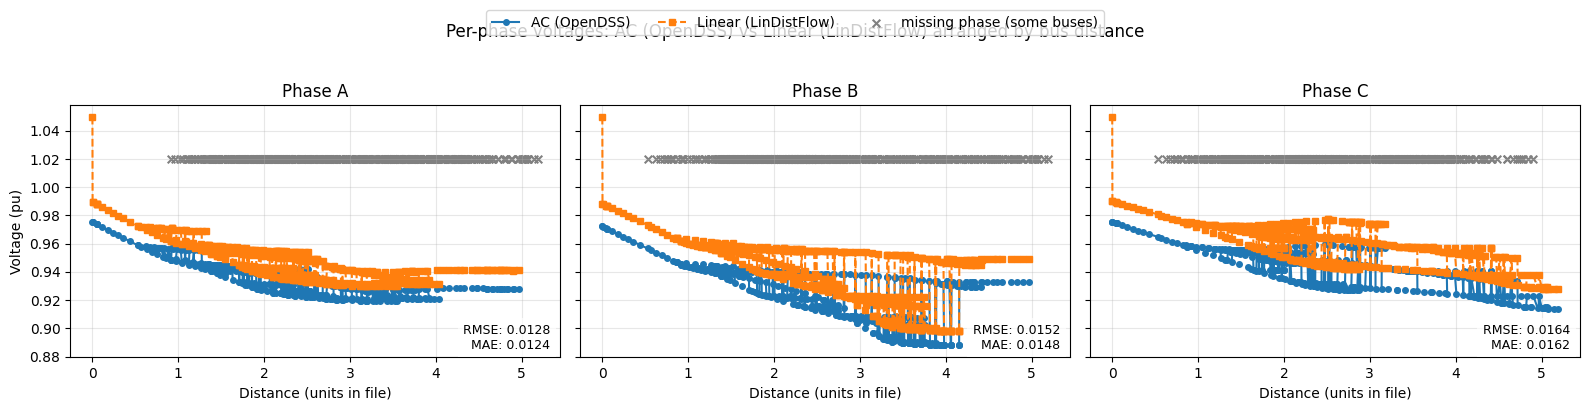


Numeric summary (overlapping buses only):
Phase A: N=506, RMSE=0.012790, mean diff=-0.012446
Phase B: N=460, RMSE=0.015216, mean diff=-0.014771
Phase C: N=495, RMSE=0.016402, mean diff=-0.016168


In [318]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt

# --- Config: paths to your exported CSVs (update if different) ---
ac_file  = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/opendss_ckt5_voltages_by_phase.csv"
lin_file = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/LinDistFlowCkt5_Vval_PV.csv"

# --- Load files ---
ac = pd.read_csv(ac_file, dtype={"bus_name": str})
lin = pd.read_csv(lin_file, dtype={"bus_name": str})

# Ensure necessary columns exist
for df,name in ((ac,'AC'),(lin,'LIN')):
    for col in ('bus_name','Va_pu','Vb_pu','Vc_pu'):
        if col not in df.columns:
            raise ValueError(f"{name} file missing required column: {col}")

# Normalize distance column sources (try a few common names)
if 'distance_ft' in ac.columns:
    dist_col = 'distance_ft'
elif 'distance' in ac.columns:
    dist_col = 'distance'
elif 'distance_km' in ac.columns:
    dist_col = 'distance_km'
else:
    # fallback: if lin has distance, use that; otherwise create an index-based distance
    if 'distance_ft' in lin.columns:
        ac['distance_ft'] = lin['distance_ft']
        dist_col = 'distance_ft'
    else:
        ac['distance_ft'] = np.arange(len(ac))
        dist_col = 'distance_ft'

# Select and rename to avoid column collisions then merge on bus_name
ac_sel = ac[['bus_name', dist_col, 'Va_pu', 'Vb_pu', 'Vc_pu']].copy()
ac_sel = ac_sel.rename(columns={dist_col: 'distance', 'Va_pu': 'Va_ac', 'Vb_pu': 'Vb_ac', 'Vc_pu': 'Vc_ac'})

lin_sel = lin[['bus_name', 'Va_pu', 'Vb_pu', 'Vc_pu']].copy().rename(
    columns={'Va_pu': 'Va_lin', 'Vb_pu': 'Vb_lin', 'Vc_pu': 'Vc_lin'}
)

merged = pd.merge(ac_sel, lin_sel, on='bus_name', how='inner')

if merged.empty:
    raise RuntimeError("No common bus_name entries found between AC and Linear files. Check bus naming.")

# Sort by distance (convert to numeric if needed)
merged['distance'] = pd.to_numeric(merged['distance'], errors='coerce')
merged = merged.sort_values('distance').reset_index(drop=True)

# Optional: convert distance units for plot (feet -> km) if applicable
# If distances look very large (ft), convert to miles/km for readability
dist = merged['distance'].values
# Heuristic: if median > 1000 assume feet and convert to km
if np.nanmedian(np.abs(dist)) > 1000:
    dist_km = dist * 0.0003048
    x_label = "Distance from substation (km)"
else:
    dist_km = dist
    x_label = "Distance (units in file)"

# --- Plotting: one subplot per phase ---
phases = [('Va_ac','Va_lin','A'), ('Vb_ac','Vb_lin','B'), ('Vc_ac','Vc_lin','C')]
fig, axes = plt.subplots(1, 3, figsize=(16,4), sharey=True)

for ax, (ac_col, lin_col, ph) in zip(axes, phases):
    # x values and y values
    x = dist_km
    y_ac  = merged[ac_col].to_numpy(dtype=float)
    y_lin = merged[lin_col].to_numpy(dtype=float)

    # Plot AC and Linear; plot markers for points and a line connecting them
    ax.plot(x, y_ac, marker='o', linestyle='-', color='tab:blue', label='AC (OpenDSS)', markersize=4)
    ax.plot(x, y_lin, marker='s', linestyle='--', color='tab:orange', label='Linear (LinDistFlow)', markersize=4)

    # Highlight buses where either model has NaN by plotting small grey x
    nan_mask = np.isnan(y_ac) | np.isnan(y_lin)
    if nan_mask.any():
        ax.scatter(np.array(x)[nan_mask], np.zeros(nan_mask.sum()) + 1.02, marker='x', color='gray', s=30, label='missing phase (some buses)')

    ax.set_xlabel(x_label)
    ax.set_title(f'Phase {ph}')
    ax.grid(alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('Voltage (pu)')

    # Compute and annotate simple error stats (RMSE) ignoring NaNs
    valid = ~(np.isnan(y_ac) | np.isnan(y_lin))
    if valid.sum() > 0:
        err = y_ac[valid] - y_lin[valid]
        rmse = sqrt(np.nanmean(err**2))
        mae  = np.nanmean(np.abs(err))
        ax.text(0.98, 0.02, f"RMSE: {rmse:.4f}\nMAE: {mae:.4f}", transform=ax.transAxes,
                ha='right', va='bottom', fontsize=9, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
    else:
        ax.text(0.5, 0.5, "No overlapping data", transform=ax.transAxes, ha='center')

# Shared legend
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.03))

plt.suptitle("Per-phase voltages: AC (OpenDSS) vs Linear (LinDistFlow) arranged by bus distance")
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# --- Print quick numeric summary per phase ---
print("\nNumeric summary (overlapping buses only):")
for ac_col, lin_col, ph in phases:
    y_ac  = merged[ac_col].to_numpy(dtype=float)
    y_lin = merged[lin_col].to_numpy(dtype=float)
    valid = ~(np.isnan(y_ac) | np.isnan(y_lin))
    if valid.sum() == 0:
        print(f"Phase {ph}: no overlapping data")
        continue
    err = y_ac[valid] - y_lin[valid]
    print(f"Phase {ph}: N={valid.sum():d}, RMSE={sqrt(np.nanmean(err**2)):.6f}, mean diff={np.nanmean(err):+.6f}")

In [319]:
#program to compare power flow in each line in linear, master_reduced and master files

# --- 2. Master_Reduced Model (OpenDSS) ---
# Replace with the path to your reduced master DSS file
master_reduced_file = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Master_ckt5_reduced.dss"
#dss.Basic.ClearAll()
dss.run_command(f"compile [{master_reduced_file}]")
dss.run_command(f"Set LoadMult={LMP}")
dss.run_command("solve")

# Get all line elements
lines = dss.Lines.AllNames()
mr_data = []
for line in lines:
    dss.Lines.Name(line)
    p = np.array(dss.CktElement.Powers())  # [P1, Q1, P2, Q2, ...] for all phases, both ends
    nph = dss.CktElement.NumPhases()
    from_bus=dss.Lines.Bus1().split(".")[0]
    to_bus=dss.Lines.Bus2().split(".")[0]
    loss = dss.CktElement.Losses()
    # Only take sending end (first nph*2 values)
    if nph==3:
        for ph in range(nph):
            mr_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": ph+1,
                "P": p[2*ph],
                "Q": p[2*ph+1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
    elif nph==2:
        phase=dss.Lines.Bus2().split(".")
        for ph in range(nph):
            mr_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": phase[ph+1],
                "P": p[2*ph],
                "Q": p[2*ph+1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
    elif nph==1:
        phase=dss.Lines.Bus2().split(".")[1]
        mr_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": phase,
                "P": p[0],
                "Q": p[1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
mr_df = pd.DataFrame(mr_data)
mr_df.to_csv("master_reduced_branch_power_flows.csv", index=False)
print("Saved Master_Reduced branch power flows to master_reduced_branch_power_flows.csv")



Saved Master_Reduced branch power flows to master_reduced_branch_power_flows.csv


/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/4236596912.py:7: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"compile [{master_reduced_file}]")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/4236596912.py:8: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"Set LoadMult={LMP}")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/4236596912.py:9: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command("solve")


In [320]:
# --- 3. Master File (OpenDSS) ---
master_file = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Master_ckt5.dss"
dss.Basic.ClearAll()
dss.run_command(f"compile [{master_file}]")
dss.run_command(f"Set LoadMult={LMP}")
dss.run_command("solve")

lines = dss.Lines.AllNames()


m_data = []
for line in lines:
    dss.Lines.Name(line)
    p = np.array(dss.CktElement.Powers())
    nph = dss.CktElement.NumPhases()
    from_bus=dss.Lines.Bus1().split(".")[0]
    to_bus=dss.Lines.Bus2().split(".")[0]
    loss = dss.CktElement.Losses()
    if nph==3:
        for ph in range(nph):
            m_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": ph+1,
                "P": p[2*ph],
                "Q": p[2*ph+1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
    elif nph==2:
        phase=dss.Lines.Bus2().split(".")
        for ph in range(nph):
            m_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": phase[ph+1],
                "P": p[2*ph],
                "Q": p[2*ph+1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
    elif nph==1:
        phase=dss.Lines.Bus2().split(".")[1]
        m_data.append({
                "from_bus": from_bus,
                "to_bus": to_bus,
                "line": line,
                "phase": phase,
                "P": p[0],
                "Q": p[1],
                "P_loss": loss[0],
                "Q_loss": loss[1]
         })
m_df = pd.DataFrame(m_data)
m_df.to_csv("master_branch_power_flows.csv", index=False)
print("Saved Master file branch power flows to master_branch_power_flows.csv")

Saved Master file branch power flows to master_branch_power_flows.csv


/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/3270197572.py:4: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"compile [{master_file}]")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/3270197572.py:5: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command(f"Set LoadMult={LMP}")
/var/folders/tf/30_1qjsn07g0m_y9r3pfljxw0000gn/T/ipykernel_47657/3270197572.py:6: DeprecationWarning: run_command is deprecated (use Command, Commands or the callable shortcut), see https://github.com/dss-extensions/OpenDSSDirect.py/issues/70
  dss.run_command("solve")


In [321]:
#linear model

# Load the updated Lineinf_numbered_bfs.txt with branch names as the last column
lineinf_path = "/Users/anamikadubey/code/opendss-storage/electricdss-tst/Version8/Distrib/EPRITestCircuits/ckt5/Lineinf_numbered_bfs.txt"
df_line = pd.read_csv(lineinf_path, sep=r"\s+", engine="python")

# Assume the last column is the DSS branch name
branch_names = df_line.iloc[:, -1].values
to_bus = df_line.iloc[:, 3].values
from_bus = df_line.iloc[:, 2].values
to_bus_num = df_line.iloc[:, 1].values
from_bus_num = df_line.iloc[:, 0].values

# Sbr_P and Sbr_Q: shape (num_branches, 3) for phases A, B, C
# If your Sbr_P and Sbr_Q include the slack branch (dummy), skip the first row
# Otherwise, use as is. Adjust as needed for your model.
Sbr_P = Sbr_P[1:] if Sbr_P.shape[0] == len(branch_names) + 1 else Sbr_P
Sbr_Q = Sbr_Q[1:] if Sbr_Q.shape[0] == len(branch_names) + 1 else Sbr_Q

data = []
for idx, name in enumerate(branch_names):
    for ph in range(3):  # 0: A, 1: B, 2: C
        data.append({
            "from_bus_num": from_bus_num[idx],
            "to_bus_num": to_bus_num[idx],
            "from_bus": from_bus[idx],
            "to_bus": to_bus[idx],
            "line": name,
            "phase": ph + 1,
            "P": Sbr_P[idx, ph].value*1000,
            "Q": Sbr_Q[idx, ph].value*1000
        })

df = pd.DataFrame(data)
df.to_csv("linear_branch_power_flows_named.csv", index=False)
print("Saved linear model branch power flows to linear_branch_power_flows_named.csv")

Saved linear model branch power flows to linear_branch_power_flows_named.csv


In [322]:
# Compare common branches in master_branch_power_flows.csv, master_reduced_branch_power_flows.csv, and linear_branch_power_flows_named.csv
import pandas as pd

# Load the CSVs
master_df = pd.read_csv("master_branch_power_flows.csv")
mr_df = pd.read_csv("master_reduced_branch_power_flows.csv")
lin_df = pd.read_csv("linear_branch_power_flows_named.csv")

# Merge on line name and phase (common branches/phases)
common = pd.merge(master_df, mr_df, on=["line", "phase"], suffixes=("_master", "_reduced"))
common = pd.merge(common, lin_df, on=["line", "phase"], suffixes=(None, "_linear"))

# Calculate differences
# common["dP"] = common["P_master"] - common["P_reduced"]
# common["dQ"] = common["Q_master"] - common["Q_reduced"]
# common["dP_linear"] = common["P_master"] - common["P"]
# common["dQ_linear"] = common["Q_master"] - common["Q"]

# Reorder columns for clarity
cols = [
    "from_bus_num", "to_bus_num", "from_bus", "to_bus",
    "line", "phase",
    "P_master", "Q_master", "P_loss_master", "Q_loss_master",
    "P_reduced", "Q_reduced", "P_loss_reduced", "Q_loss_reduced",
    "P", "Q"
 ]
common = common[cols]

# Save to CSV
common.to_csv("branch_power_flow_comparison_with_linear.csv", index=False)
print("Comparison of common branches (including linear model) saved to branch_power_flow_comparison_with_linear.csv")
print(common.head())

Comparison of common branches (including linear model) saved to branch_power_flow_comparison_with_linear.csv
   from_bus_num  to_bus_num        from_bus  to_bus                    line  \
0             1           2  _mdv_sub_1_lsb  mdv201        mdv201_connector   
1             1           2  _mdv_sub_1_lsb  mdv201        mdv201_connector   
2             1           2  _mdv_sub_1_lsb  mdv201        mdv201_connector   
3           804         817           94743   94744  mdv201_hn_1_275_a94744   
4           365         389           62244   62235  mdv201_hn_2_466_c62235   

   phase     P_master     Q_master  P_loss_master  Q_loss_master    P_reduced  \
0      1  4420.602202  2097.245265       1.501359      15.013589  4598.144067   
1      2  4693.393932  2139.606669       1.501359      15.013589  4870.438937   
2      3  4370.473434  2056.995753       1.501359      15.013589  4554.450985   
3      1    10.924933     4.719804       0.274345      -8.965052    11.206403   
4      3   